# Fine-tuning Qwen2.5-1.5B on GSM8K with LoRA: does it actually help?

**Question this notebook answers:** if we LoRA fine-tune `Qwen2.5-1.5B-Instruct`
on GSM8K's training rationales, does its accuracy on held-out GSM8K math
problems go up, and by how much can we actually claim to have measured?

**Method, in one paragraph:** load the base model once; score it, pristine, on
200 held-out test problems it has never been trained on; fine-tune a LoRA
adapter on the official GSM8K train split; reload the adapter *from disk* (not
the in-memory trained object) and score the same 200 problems again; then
compare the two scores with paired statistics (not just a bare percentage
difference), because both models are being asked the exact same questions.

**Two things worth knowing before you read a number out of this notebook:**

1. GSM8K is one of the most widely used math instruction-tuning datasets in
   existence, and `Qwen2.5-1.5B-Instruct` was already instruction-tuned before
   we ever touch it. It is likely the base model has already seen data very
   similar to (if not overlapping) what we're about to fine-tune on. So this
   notebook is not really testing "can LoRA teach a model new math" -- it's
   testing "does adapting the model to *this exact answer format and style*
   change its measured accuracy." That's a real and useful question, just a
   narrower one than "did we make it better at math."
2. GSM8K's gold rationales are short and terse (mean ~90 tokens). Qwen's own
   native chain-of-thought on these problems tends to run longer. Training on
   short rationales could easily make the model *more* format-compliant but
   *not more accurate* -- or even less accurate, if it starts truncating its
   own reasoning to match the terse training style. A flat or negative result
   here is a legitimate, useful finding, not a bug in the notebook.


## 1. Dependencies

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)


Running in Colab: False


### CUDA-enabled torch (local machines only)

Colab's runtime already ships a CUDA-enabled torch, so there's nothing to do
there. On a local machine, `pip` can silently install (or leave in place) a
**CPU-only** build of torch, which this whole notebook needs to not do --
everything downstream assumes a GPU.

The cell below installs the CUDA 13.2 wheels, which match driver-reported
CUDA 13.3 (minor-version skew between the driver and the wheel's CUDA runtime
is expected and fine). **If this cell actually installs something, restart the
kernel before continuing** -- the already-imported CPU build otherwise stays
in memory for the rest of the session.


In [2]:
if not IN_COLAB:
    %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132
else:
    print("Colab already ships a CUDA-enabled torch -- skipping reinstall.")


Looking in indexes: https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


In [3]:
# The rest of the stack, both environments. Notably absent: `bitsandbytes` and
# `trl`. We don't need bitsandbytes because we train in bf16/fp16 rather than
# 4-bit (see the USE_4BIT note in Configuration, below) -- it's the source of
# the fragile installs and Windows file-lock errors in the original version of
# this notebook. We don't need trl because we build training examples by hand
# with explicit label masking (see Section 10), which keeps the exact string a
# model is trained on fully visible in this notebook rather than hidden inside
# a training-framework's internal templating.
%pip install -q -U transformers datasets peft accelerate matplotlib


Note: you may need to restart the kernel to use updated packages.


## 2. Environment

In [4]:
import os, re, sys, json, math, time, gc

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
# Must be set before `import torch` initializes CUDA. Reduces allocator
# fragmentation, which can otherwise cause a near-full-VRAM allocation to
# fail (or silently spill to slow system-memory fallback, see Section 3) even
# when enough memory is technically free across smaller unused blocks.

from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType

IN_COLAB = "google.colab" in sys.modules

assert torch.cuda.is_available(), (
    "No CUDA device visible to torch. If you're on a local machine, install the "
    "CUDA build and RESTART THE KERNEL:\n"
    "  %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132"
)

SUPPORTS_BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if SUPPORTS_BF16 else torch.float16


def gpu_mem():
    return (f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated / "
            f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


print(f"torch:          {torch.__version__}")
print(f"Device:         {torch.cuda.get_device_name(0)}")
print(f"VRAM:           {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"bf16 support:   {SUPPORTS_BF16}")
print(f"Compute dtype:  {COMPUTE_DTYPE}")
print(f"In Colab:       {IN_COLAB}")

d:\Projects\Algoverse\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0808 21:41:22.429000 41208 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0808 21:41:22.491000 41208 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0808 21:41:23.124000 41208 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


torch:          2.13.0+cu132
Device:         NVIDIA GeForce RTX 3080 Ti Laptop GPU
VRAM:           17.2 GB
bf16 support:   True
Compute dtype:  torch.bfloat16
In Colab:       False


## 3. Configuration

Every path and hyperparameter lives here, in one place, so a re-run with
different settings never means hunting through the notebook.


In [5]:
SMOKE = False
# True -> a tiny end-to-end run (a few dozen examples, a handful of training
# steps) that exercises every cell in under a couple of minutes, to catch a
# broken cell before committing to a real run. The accuracy numbers it
# produces are meaningless (too few examples) -- it only proves the plumbing
# works. Flip back to False for a real run.

SEED = 0
BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

N_VAL  = 16 if SMOKE else 200    # held out from *train*, used only for the eval-loss curve
N_EVAL = 16 if SMOKE else 200    # drawn from the official *test* split -- the headline comparison
N_TRAIN_CAP = 64 if SMOKE else 2000   # cap on training examples (None = everything left after the N_VAL holdout)

EPOCHS         = 1 if SMOKE else 3
# With only 2,000 training examples (vs. the full ~7,273-example train split),
# one epoch is just ~125 optimizer steps at the effective batch size below --
# too few weight updates for the adapter to move much. 3 epochs (~375 steps)
# gets back into a range where LoRA fine-tuning on a dataset this size
# typically shows a real effect, at the cost of each example being seen
# multiple times. (In practice this is now an upper bound, not a target --
# EarlyStoppingCallback in Section 12 will halt training sooner if dev loss
# plateaus first.)
LEARNING_RATE  = 1e-4
BATCH_SIZE     = 2
GRAD_ACCUM     = 8
MAX_LENGTH     = 384     # lowered from 448 to cap the worst-case per-batch memory spike --
                          # dynamic padding pads to the batch's longest member, so one
                          # unusually long example still sets memory usage for the whole
                          # batch. 384 still comfortably covers the typical example (measured
                          # mean ~200 tokens); only the longest tail gets truncated.
MAX_NEW_TOKENS = 400     # generation budget at eval time; generous enough that a verbose
                          # base-model answer isn't cut off mid-reasoning (measured gold p99
                          # rationale length is ~216 tokens; native Qwen CoT can run longer)
GEN_BATCH_SIZE = 32      # batched greedy-generation batch size (see Section 8 for the memory math)

LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.1
# Bumped from 0.05: with EPOCHS=3 over only 2,000 examples, each training
# example is revisited multiple times, which raises overfitting risk relative
# to the original single-epoch/full-train-split setup. A bit more dropout on
# the LoRA path is cheap insurance against memorizing the smaller slice.
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",      # attention
    "gate_proj", "up_proj", "down_proj",          # MLP -- style/format adaptation happens here too
]

USE_4BIT = False
# Qwen2.5-1.5B fits comfortably in bf16 on any 16GB+ GPU (~3.1GB of weights), so
# 4-bit quantization -- a *memory* optimization -- isn't needed here, and it
# actively costs speed (every forward pass has to dequantize) and blocks a
# clean `merge_and_unload()` into a standalone model. Flip this on only if you
# scale up to a much larger model that doesn't fit otherwise.
GRAD_CHECKPOINTING = True   # recomputes activations during backward instead of storing them --
                            # ~20-30% slower per step, but substantially cuts activation memory
                            # (the dominant consumer once training starts). Enabled after an
                            # earlier run on this machine crept up to ~98% VRAM use and
                            # collapsed into Windows' silent CUDA-to-system-memory fallback.

SYSTEM_PROMPT = (
    "You are a careful math assistant. Solve the problem step by step, then "
    "give the final numeric answer on its own last line in exactly this "
    "form:\n#### <number>"
)
# Pinned explicitly rather than left blank: Qwen's chat template silently
# substitutes its own default system message ("You are Qwen, created by
# Alibaba Cloud...") when none is given. Leaving it unpinned would mean the
# exact prompt text depends on whichever default the template ships with --
# pin it so training and eval are guaranteed to share the same prompt.

OUTPUT_ROOT = (
    "/content/drive/MyDrive/algoverse/gsm8k_lora"
    if IN_COLAB and os.path.exists("/content/drive")
    else "./models/qwen2.5-1.5b-gsm8k-lora"
)
ADAPTER_DIR = os.path.join(OUTPUT_ROOT, "adapter")
MERGED_DIR  = os.path.join(OUTPUT_ROOT, "merged")
RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
for d in (ADAPTER_DIR, MERGED_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

set_seed(SEED)
print(f"SMOKE test mode: {SMOKE}")
print(f"Output root:     {OUTPUT_ROOT}")

SMOKE test mode: False
Output root:     ./models/qwen2.5-1.5b-gsm8k-lora


## 4. Load the tokenizer and base model -- once

This is the *only* place the base model is loaded. Every section below --
baseline scoring, LoRA training, and the final post-training scoring -- reuses
these same two objects, so there's no risk of accidentally comparing two
subtly different model instances.


In [6]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
# Qwen2.5 already ships a distinct pad token (<|endoftext|>), separate from its
# eos token (<|im_end|>). Unlike some Llama-family checkpoints, there's no need
# to alias pad_token = eos_token here -- doing so (as the original version of
# this notebook did) makes padded positions indistinguishable from a genuine
# end-of-sequence token, and is exactly what produced the "PAD/BOS/EOS tokens
# differ from the model config" warning in that version.
print(f"pad_token: {tokenizer.pad_token!r} ({tokenizer.pad_token_id})")
print(f"eos_token: {tokenizer.eos_token!r} ({tokenizer.eos_token_id})")

quantization_config = None
if USE_4BIT:
    from transformers import BitsAndBytesConfig
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        bnb_4bit_use_double_quant=True,
    )

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    dtype=COMPUTE_DTYPE,
    quantization_config=quantization_config,
    device_map={"": 0},
)
base_model.config.use_cache = True

print(f"\nLoaded {BASE_MODEL_ID} in {COMPUTE_DTYPE}.")
print(f"Memory: {gpu_mem()}")


pad_token: '<|endoftext|>' (151643)
eos_token: '<|im_end|>' (151645)


d:\Projects\Algoverse\.venv\Lib\site-packages\transformers\modeling_utils.py:5198: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  _ = torch.empty(int(byte_count // 2), dtype=torch.float16, device=device, requires_grad=False)
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 347.02it/s]



Loaded Qwen/Qwen2.5-1.5B-Instruct in torch.bfloat16.
Memory: 3.09 GB allocated / 3.15 GB reserved


## 5. Data

We use GSM8K's **official** train and test splits -- not a hand-rolled split
of the train set, which is what the original version of this notebook did
(leaving the real 1319-example test split completely unused). A fixed seed
makes the sampling reproducible.


In [7]:
raw_train = load_dataset("openai/gsm8k", "main", split="train")
raw_test  = load_dataset("openai/gsm8k", "main", split="test")
print(f"Official train split: {len(raw_train)} | Official test split: {len(raw_test)}")

shuffled_train = raw_train.shuffle(seed=SEED)
dev_rows   = shuffled_train.select(range(N_VAL))
train_rows = shuffled_train.select(range(N_VAL, len(shuffled_train)))
if N_TRAIN_CAP is not None:
    train_rows = train_rows.select(range(min(N_TRAIN_CAP, len(train_rows))))

test_rows = raw_test.shuffle(seed=SEED).select(range(min(N_EVAL, len(raw_test))))

# Defensive check: the headline eval set must never share a question with
# what the model was trained on.
assert set(train_rows["question"]).isdisjoint(test_rows["question"])
assert set(dev_rows["question"]).isdisjoint(test_rows["question"])

print(f"train {len(train_rows)} (fine-tuning)")
print(f"dev   {len(dev_rows)} (held out from train, eval-loss curve only)")
print(f"test  {len(test_rows)} (official test split, headline comparison)")

print(f"\n--- sample gold answer ---\n{train_rows[0]['answer']}")


Official train split: 7473 | Official test split: 1319
train 2000 (fine-tuning)
dev   200 (held out from train, eval-loss curve only)
test  200 (official test split, headline comparison)

--- sample gold answer ---
At the beginning, Jacob had 8 fish
Alex had 7 * 8 = <<7*8=56>>56 fish
After knocking the bucket over, Alex was left with 56 - 23 = <<56-23=33>>33 fish left.
The final amount caught by Jacob to beat Alex by 1 fish is 33 +1 = <<33+1=34>>34 fish.
Then Jacob needs to catch 34 - 8 = <<34-8=26>>26 fish more.
#### 26


## 6. Prompt format -- the fairness problem

`Qwen2.5-1.5B-Instruct` is *already* a capable instruction-tuned model on
grade-school math. If we trained on one prompt format (say, a custom
`### Instruction:` template) and then evaluated the *base* model in that same
unfamiliar format, most of the measured "improvement" would really be the base
model being handicapped by an alien prompt -- not the LoRA teaching it
anything.

**Resolution:** both models see the exact same prompt, built by the exact same
function (`to_chat_example`, below), using Qwen's own chat template with an
explicit, pinned system prompt. Because training examples are built by calling
this same function (Section 10), the training prompt and the eval prompt are
identical by construction -- there's no separate "training format" and "eval
format" that could quietly drift apart.


In [8]:
def to_chat_example(question: str) -> str:
    """Render one GSM8K question as a Qwen chat prompt, ready for generation.
    Reused for both training examples and every eval call below."""
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ],
        tokenize=False,
        add_generation_prompt=True,
    )


# Demonstrate why the system prompt is pinned explicitly: this is what Qwen's
# template renders when no system message is given at all.
_unpinned = tokenizer.apply_chat_template(
    [{"role": "user", "content": "PROBE"}], tokenize=False, add_generation_prompt=True
)
print("Qwen's default when no system message is given:")
print(f"  {_unpinned!r}")
print("\nOur pinned version:")
print(f"  {to_chat_example('PROBE')!r}")


Qwen's default when no system message is given:
  '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nPROBE<|im_end|>\n<|im_start|>assistant\n'

Our pinned version:
  '<|im_start|>system\nYou are a careful math assistant. Solve the problem step by step, then give the final numeric answer on its own last line in exactly this form:\n#### <number><|im_end|>\n<|im_start|>user\nPROBE<|im_end|>\n<|im_start|>assistant\n'


## 7. Answer extraction and scoring

GSM8K's gold answers always end with a `#### <integer>` line -- we verify that
below rather than assume it. Model generations are messier: they might follow
that convention, or might just state a number in prose. We use `Decimal`
rather than `float` for comparison so that `72` and `72.0` compare exactly
equal with no floating-point rounding involved.


In [9]:
CALC_RE = re.compile(r"<<[^>]*>>")
_NUM = r"-?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?"
HASH_RE = re.compile(r"####\s*\$?\s*(" + _NUM + r")")
NUM_RE  = re.compile(_NUM)


def clean_target(answer: str) -> str:
    """Strip GSM8K's inline <<calculator>> annotations from a training target,
    e.g. '48/2 = <<48/2=24>>24' -> '48/2 = 24'. These are a dataset-authoring
    artifact (a scratch-calculator trace), not something worth the model
    reproducing verbatim. Measured effect: they appear in ~99% of rationales
    and stripping them cuts mean target length by roughly 15%, which is a
    direct training- and generation-time saving. It does NOT change how
    reliably we can extract the final answer -- the '#### N' line they
    surround is untouched either way."""
    return CALC_RE.sub("", answer)


def to_decimal(s):
    """Parse a matched number string into a Decimal, tolerating '$', ',',
    '%', and a trailing period."""
    if s is None:
        return None
    s = s.strip().replace(",", "").replace("$", "").replace("%", "").rstrip(".")
    try:
        return Decimal(s)
    except InvalidOperation:
        return None


def extract_gold(answer: str) -> Decimal:
    m = HASH_RE.search(answer)
    assert m is not None, f"gold answer has no '#### N' line: {answer!r}"
    return to_decimal(m.group(1))


def extract_pred(text: str):
    """Pull the model's final numeric answer out of free-form generated
    text. Primary: the LAST '#### N' occurrence (a model that restates the
    question before answering could otherwise match the wrong one). Fallback:
    the last number anywhere in the text, for generations that never emit the
    '####' marker. Returns (value, method) -- `method` lets us report how
    often each model needed the less-reliable fallback."""
    hashes = list(HASH_RE.finditer(text))
    if hashes:
        v = to_decimal(hashes[-1].group(1))
        if v is not None:
            return v, "hash"
    nums = NUM_RE.findall(text)
    if nums:
        return to_decimal(nums[-1]), "last_number"
    return None, "none"


def is_correct(pred, gold) -> bool:
    return pred is not None and pred == gold


# Self-test against formats we've actually seen in real generations.
_cases = [
    ("blah blah #### 72", "72"),
    ("The total is $1,080 dollars.\n#### 1,080", "1080"),
    ("#### -5", "-5"),
    ("no marker, but the answer is 42 apples", "42"),
    ("nothing numeric here", None),
]
for text, expected in _cases:
    got, _ = extract_pred(text)
    want = Decimal(expected) if expected is not None else None
    assert got == want, (text, got, want)
print(f"extract_pred self-test passed ({len(_cases)} cases).")

assert all(extract_gold(a) is not None for a in raw_train["answer"][:500]), "unexpected gold format"
print("Gold-answer '#### N' format verified on a sample of the training set.")


extract_pred self-test passed (5 cases).
Gold-answer '#### N' format verified on a sample of the training set.


## 8. Batched generation and the shared evaluation harness

Defined **before** training, so the exact same `evaluate()` function scores
both the pristine base model and the fine-tuned model later -- no chance of
the two being measured differently.

Two details matter for batched generation with a decoder-only model:

- **`padding_side` must be `"left"` during generation.** Right-padding is
  correct for training, but at generation time it pushes real tokens away
  from position 0 for every prompt shorter than the batch's longest one,
  which corrupts position ids for anything but the single longest sequence in
  the batch. We flip it here and restore the original setting afterward.
- **Sorting prompts by length before batching** keeps each batch's members
  close in length, which minimizes wasted padding compute -- a batch's cost is
  set by its longest member. We restore the original order before returning.

Qwen2.5-1.5B in bf16 is ~3.1GB of weights; at `GEN_BATCH_SIZE=32` and a few
hundred tokens per sequence the KV cache adds well under 1GB (this model uses
grouped-query attention with only 2 KV heads), so generation has plenty of
headroom on a 16GB GPU.


In [10]:
def generate_batch(model, prompts, max_new_tokens=None, batch_size=None):
    """Greedy-decode a batch of prompts. Returns (texts, n_new_tokens),
    aligned to `prompts`."""
    max_new_tokens = max_new_tokens or MAX_NEW_TOKENS
    batch_size = batch_size or GEN_BATCH_SIZE

    original_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    model.eval()

    eos_ids = [tokenizer.eos_token_id]
    endoftext_id = tokenizer.convert_tokens_to_ids("<|endoftext|>")
    if endoftext_id is not None and endoftext_id not in eos_ids:
        eos_ids.append(endoftext_id)

    order = sorted(range(len(prompts)), key=lambda i: len(prompts[i]))
    texts = [None] * len(prompts)
    n_new_tokens = [0] * len(prompts)

    try:
        with torch.inference_mode():
            for start in range(0, len(order), batch_size):
                idx = order[start:start + batch_size]
                batch = [prompts[i] for i in idx]
                inputs = tokenizer(batch, return_tensors="pt", padding=True).to(model.device)
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,   # greedy -> reproducible
                    eos_token_id=eos_ids,
                    pad_token_id=tokenizer.pad_token_id,
                )
                new_tokens = out[:, inputs["input_ids"].shape[1]:]
                decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
                for i, ids, text in zip(idx, new_tokens, decoded):
                    texts[i] = text.strip()
                    n_new_tokens[i] = int((ids != tokenizer.pad_token_id).sum())
    finally:
        tokenizer.padding_side = original_side

    return texts, n_new_tokens


def evaluate(model, rows, tag, verbose_examples=3):
    """Score `model` against `rows` (a GSM8K-format dataset slice), using the
    SAME harness every time. Returns one DataFrame row per example."""
    prompts = [to_chat_example(r["question"]) for r in rows]
    t0 = time.time()
    generations, n_new_tokens = generate_batch(model, prompts)
    elapsed = time.time() - t0

    records = []
    for row, gen, ntok in zip(rows, generations, n_new_tokens):
        gold = extract_gold(row["answer"])
        pred, method = extract_pred(gen)
        records.append({
            "question": row["question"],
            "gold": gold,
            "prediction": gen,
            "pred_value": pred,
            "pred_method": method,
            "n_new_tokens": ntok,
            "correct": is_correct(pred, gold),
        })
    df = pd.DataFrame(records)
    acc = df["correct"].mean()
    compliance = (df["pred_method"] == "hash").mean()
    print(f"{tag}: {df['correct'].sum()}/{len(df)} correct = {acc:.1%}  |  "
          f"'####' compliance {compliance:.1%}  |  "
          f"mean {df['n_new_tokens'].mean():.0f} new tokens  |  "
          f"{elapsed:.0f}s ({elapsed/len(df):.2f}s/example)")

    for _, r in df.head(verbose_examples).iterrows():
        flag = "correct" if r["correct"] else "wrong"
        print(f"  [{flag}] gold={r['gold']}  pred={r['pred_value']}  (via {r['pred_method']})")

    return df


## 9. Score the pristine base model

This runs against `base_model` before any LoRA adapter exists -- no ambiguity
about whether we're seeing base or fine-tuned behavior.


In [11]:
print("Scoring the PRISTINE base model (no adapter attached) ...\n")
base_df = evaluate(base_model, test_rows, tag="BASE MODEL")
base_acc = base_df["correct"].mean()


Scoring the PRISTINE base model (no adapter attached) ...

BASE MODEL: 132/200 correct = 66.0%  |  '####' compliance 0.0%  |  mean 269 new tokens  |  101s (0.51s/example)
  [correct] gold=400  pred=400  (via last_number)
  [wrong] gold=25  pred=37.5  (via last_number)
  [correct] gold=3  pred=3  (via last_number)


## 10. Build the training set

Each example is `to_chat_example(question)` (the *same* function used for
eval) followed by the cleaned answer and an explicit end-of-sequence token,
with the prompt span masked out of the loss (`-100`) so the model is only ever
trained to predict the answer, never to reproduce the question.


In [12]:
def build_example(question, answer):
    """Return (input_ids, labels) for one training example."""
    prompt = to_chat_example(question)
    target = clean_target(answer)
    full_text = prompt + target + tokenizer.eos_token

    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"][:MAX_LENGTH]

    n_masked = min(len(prompt_ids), len(full_ids))
    labels = [-100] * n_masked + full_ids[n_masked:]
    return full_ids, labels


# Guard: the prompt must be a clean token prefix of the full sequence, or the
# -100 mask above would silently land on the wrong tokens (e.g. if the
# tokenizer merged a token across the prompt/answer boundary).
_probe_q = train_rows[0]["question"]
_probe_prompt = to_chat_example(_probe_q)
_probe_ids = tokenizer(_probe_prompt, add_special_tokens=False)["input_ids"]
_probe_full = tokenizer(
    _probe_prompt + clean_target(train_rows[0]["answer"]) + tokenizer.eos_token,
    add_special_tokens=False,
)["input_ids"]
assert _probe_full[:len(_probe_ids)] == _probe_ids, (
    "Prompt is not a clean token prefix of the full sequence -- label masking would misalign."
)
print("Prompt/answer token boundary verified clean.")

train_examples = [build_example(r["question"], r["answer"]) for r in train_rows]
dev_examples   = [build_example(r["question"], r["answer"]) for r in dev_rows]

lengths = [len(ids) for ids, _ in train_examples]
print(f"\n{len(train_examples)} training examples | "
      f"length mean {np.mean(lengths):.0f}, p95 {np.percentile(lengths, 95):.0f}, "
      f"max {max(lengths)} tokens (cap {MAX_LENGTH})")


def to_hf_dataset(examples):
    return Dataset.from_dict({
        "input_ids": [ids for ids, _ in examples],
        "labels":    [labels for _, labels in examples],
    })


train_dataset = to_hf_dataset(train_examples)
dev_dataset   = to_hf_dataset(dev_examples)

# Pads each batch to its own longest member (not to MAX_LENGTH), and pads
# labels with -100 so padding never contributes to the loss.
data_collator = DataCollatorForSeq2Seq(tokenizer, padding=True, label_pad_token_id=-100)

# Sanity check the mask on one example: prompt masked, answer supervised.
_ids0, _labels0 = train_examples[0]
_n_masked = sum(1 for l in _labels0 if l == -100)
print(f"\nExample 0: {len(_ids0)} tokens, {_n_masked} masked (prompt), "
      f"{len(_ids0) - _n_masked} supervised (answer)")


Prompt/answer token boundary verified clean.

2000 training examples | length mean 200, p95 308, max 384 tokens (cap 384)

Example 0: 223 tokens, 128 masked (prompt), 95 supervised (answer)


## 11. Attach the LoRA adapter

Targets both attention (`q/k/v/o_proj`) and the MLP (`gate/up/down_proj`).
Attention-only adapters are common, but the MLP is where a lot of a
transformer's format- and style-level behavior lives, and that's the main
thing we expect this fine-tune to change.


In [13]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.enable_input_require_grads()
peft_model.print_trainable_parameters()

# LoRA params must stay in fp32 for optimizer updates of size (lr * grad) to
# not round away against a bf16/fp16 base -- PEFT does this by default, but
# check rather than assume.
trainable_dtypes = {p.dtype for p in peft_model.parameters() if p.requires_grad}
print(f"Trainable parameter dtypes: {trainable_dtypes}")
assert trainable_dtypes == {torch.float32}, "expected all trainable (LoRA) params in fp32"


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
Trainable parameter dtypes: {torch.float32}


## 12. Train

`bf16`/`fp16` is chosen automatically from what the GPU supports (Section 2).
Gradient checkpointing is on (Section 3) -- trading ~20-30% more compute time
per step for substantially lower activation memory, after an earlier run on
this machine crept up to ~98% VRAM usage and collapsed into Windows' silent
CUDA-to-system-memory fallback. 4-bit quantization is still skipped: it would
save more memory but costs even more speed and blocks a clean
`merge_and_unload()`.

Evaluation runs periodically against the held-out `dev` set (from *train*,
never *test*) for two purposes now, not just the loss curve in Section 17:
`load_best_model_at_end` tracks whichever checkpoint had the lowest `dev`
loss and restores *that* one when training finishes (rather than whatever the
final step happens to be), and `EarlyStoppingCallback` halts training once
`dev` loss has failed to improve for a few evaluations in a row -- catching
the model overfitting the small 2,000-example training slice instead of
training straight through it. Neither plays any role in the final accuracy
comparison, which is scored only on `test`.

In [14]:
gc.collect()
torch.cuda.empty_cache()
peft_model.config.use_cache = False
# use_cache=True (set on base_model earlier, for the baseline-scoring
# generation calls) makes the forward pass retain per-layer K/V outputs it
# has no use for during training -- turned off here, and back on in
# Section 14 before eval resumes.
print(f"Memory before training: {gpu_mem()}")

effective_batch = BATCH_SIZE * GRAD_ACCUM
steps_per_epoch = max(1, -(-len(train_dataset) // effective_batch))   # ceil division
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))
eval_steps = max(1, total_steps // 10)

print(f"{len(train_dataset)} examples | micro-batch {BATCH_SIZE} x accum {GRAD_ACCUM} "
      f"= effective batch {effective_batch}")
print(f"{total_steps} total steps ({steps_per_epoch}/epoch), {warmup_steps} warmup\n")

training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_ROOT, "checkpoints"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=GRAD_CHECKPOINTING,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    logging_steps=max(1, total_steps // 20),
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,          # must match eval_steps for load_best_model_at_end
    save_total_limit=2,             # keep disk usage bounded to the 2 most relevant checkpoints
    load_best_model_at_end=True,    # restore the lowest-dev-loss checkpoint, not just the last step
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=SUPPORTS_BF16,
    fp16=not SUPPORTS_BF16,
    optim="adamw_torch",
    report_to="none",
    seed=SEED,
    dataloader_drop_last=False,
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    # Stops once dev loss hasn't improved for 3 straight evals (~1 epoch of
    # patience here) -- tolerates a noisy single uptick without stopping on
    # it, while `load_best_model_at_end` above still restores the true
    # lowest-dev-loss checkpoint rather than whichever step training halts on.
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Training...")
train_result = trainer.train()

print(f"\nFinal training loss: {train_result.training_loss:.4f}")
print(f"Peak memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

Memory before training: 3.17 GB allocated / 3.21 GB reserved
2000 examples | micro-batch 2 x accum 8 = effective batch 16
375 total steps (125/epoch), 37 warmup

Training...


Step,Training Loss,Validation Loss
37,0.451254,0.464952
74,0.462010,0.452800
111,0.436931,0.449817
148,0.376006,0.452005
185,0.377444,0.457415
222,0.382390,0.456884


d:\Projects\Algoverse\.venv\Lib\site-packages\peft\utils\other.py:1496: UserWarning: Unable to fetch remote file due to the following error [WinError 10054] An existing connection was forcibly closed by the remote host - silently ignoring the lookup for the file config.json in Qwen/Qwen2.5-1.5B-Instruct.
  warnings.warn(
d:\Projects\Algoverse\.venv\Lib\site-packages\peft\utils\save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen2.5-1.5B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
d:\Projects\Algoverse\.venv\Lib\site-packages\peft\utils\other.py:1496: UserWarning: Unable to fetch remote file due to the following error [WinError 10054] An existing connection was forcibly closed by the remote host - silently ignoring the lookup for the file config.json in Qwen/Qwen2.5-1.5B-Instruct.
  warnings.warn(
d:\Projects\Algoverse\.venv\Lib\site-packages\peft\utils\save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen2


Final training loss: 0.4229
Peak memory: 4.88 GB


## 13. Save the adapter

Saves only the LoRA weights (a few dozen MB), not the full base model.


In [15]:
peft_model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

with open(os.path.join(RESULTS_DIR, "train_log.json"), "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

print(f"Adapter saved to {ADAPTER_DIR}")
for fname in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, fname))
    print(f"  {fname:<32} {size/1e6:.2f} MB")


Adapter saved to ./models/qwen2.5-1.5b-gsm8k-lora\adapter
  README.md                        0.01 MB
  adapter_config.json              0.00 MB
  adapter_model.safetensors        73.91 MB
  chat_template.jinja              0.00 MB
  tokenizer.json                   11.42 MB
  tokenizer_config.json            0.00 MB


## 14. Reload the adapter from disk, verify it round-trips, then score

The model scored here is loaded **from the saved adapter directory**, not the
in-memory object that just finished training -- so the reported number
reflects the artifact actually saved to disk, not whatever happens to still
be sitting in memory. `load_adapter` reads the saved weights back in under a
new name; `set_adapter` makes that reloaded copy the active one for
generation.

Before trusting that reload, we run a small self-check: temporarily disabling
the adapter should reproduce (or very nearly reproduce) the pristine base
model's behavior from Section 9 on the same handful of prompts.


In [16]:
gc.collect()
torch.cuda.empty_cache()
peft_model.config.use_cache = True

# Self-check: with the adapter disabled, this should behave like the pristine
# base model did in Section 9. Greedy batched decoding isn't bit-for-bit
# deterministic across different batch compositions (padding changes the
# order floating-point additions happen in), so we compare extracted answers,
# not raw strings.
_probe_rows = test_rows.select(range(min(8, len(test_rows))))
_probe_prompts = [to_chat_example(r["question"]) for r in _probe_rows]
with peft_model.disable_adapter():
    _check_texts, _ = generate_batch(peft_model, _probe_prompts)
_check_preds = [extract_pred(t)[0] for t in _check_texts]
_base_preds = [extract_pred(t)[0] for t in base_df["prediction"].iloc[:len(_probe_rows)]]
_matches = sum(a == b for a, b in zip(_check_preds, _base_preds))
print(f"Adapter-disabled reproduces base predictions: {_matches}/{len(_probe_rows)}")

if "from_disk" not in peft_model.peft_config:
    peft_model.load_adapter(ADAPTER_DIR, adapter_name="from_disk")
peft_model.set_adapter("from_disk")

print("\nScoring the FINE-TUNED model (adapter reloaded from disk) ...\n")
tuned_df = evaluate(peft_model, test_rows, tag="FINE-TUNED MODEL (from disk)")
tuned_acc = tuned_df["correct"].mean()


Adapter-disabled reproduces base predictions: 7/8

Scoring the FINE-TUNED model (adapter reloaded from disk) ...

FINE-TUNED MODEL (from disk): 88/200 correct = 44.0%  |  '####' compliance 99.5%  |  mean 86 new tokens  |  90s (0.45s/example)
  [correct] gold=400  pred=400  (via hash)
  [wrong] gold=25  pred=50  (via hash)
  [correct] gold=3  pred=3  (via hash)


## 15. Save a standalone merged model

A bonus deliverable: merging the LoRA weights into the base model produces a
plain, standalone model that doesn't need `peft` installed to load later. This
is only possible because we skipped 4-bit quantization in Section 4 -- merging
LoRA weights into a quantized base isn't supported the same way.


In [17]:
merged_model = peft_model.merge_and_unload()
merged_model.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)

print(f"Standalone merged model saved to {MERGED_DIR}")
for fname in sorted(os.listdir(MERGED_DIR)):
    size = os.path.getsize(os.path.join(MERGED_DIR, fname))
    print(f"  {fname:<32} {size/1e6:.2f} MB")


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.98s/it]

Standalone merged model saved to ./models/qwen2.5-1.5b-gsm8k-lora\merged
  chat_template.jinja              0.00 MB
  config.json                      0.00 MB
  generation_config.json           0.00 MB
  model.safetensors                3087.47 MB
  tokenizer.json                   11.42 MB
  tokenizer_config.json            0.00 MB


## 16. Paired statistics

Base and fine-tuned were scored on the **same** 200 test questions, in the
same order, so this is a paired comparison, not two independent samples.
That matters: two marginal accuracy confidence intervals can overlap heavily
while the paired difference is still clearly nonzero, because most of each
model's individual uncertainty comes from the *same* questions being easy or
hard for both. McNemar's test looks only at the questions where the two
models disagree, which is where the actual evidence about a difference lives.


In [18]:
def wilson_ci(k, n, z=1.959963985):
    """Wilson score interval for a binomial proportion -- well-behaved even
    at small n or accuracies near 0%/100%, unlike the naive normal
    approximation."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def mcnemar_exact_p(b, c):
    """Exact two-sided McNemar test on the discordant pairs (b = base-only-
    correct, c = tuned-only-correct). Dependency-free (scipy isn't installed
    in this environment): under the null hypothesis a discordant pair is
    equally likely to go either way, so b ~ Binomial(b + c, 0.5)."""
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    tail = sum(math.comb(n, i) for i in range(k + 1)) * (0.5 ** n)
    return min(1.0, 2 * tail)


paired = pd.DataFrame({
    "question":      base_df["question"],
    "gold":          base_df["gold"],
    "base_correct":  base_df["correct"],
    "tuned_correct": tuned_df["correct"],
})

both_correct = int((paired.base_correct & paired.tuned_correct).sum())
base_only    = int((paired.base_correct & ~paired.tuned_correct).sum())
tuned_only   = int((~paired.base_correct & paired.tuned_correct).sum())
both_wrong   = int((~paired.base_correct & ~paired.tuned_correct).sum())

base_lo, base_hi   = wilson_ci(int(paired.base_correct.sum()), len(paired))
tuned_lo, tuned_hi = wilson_ci(int(paired.tuned_correct.sum()), len(paired))
p_value = mcnemar_exact_p(base_only, tuned_only)
discordance = (base_only + tuned_only) / len(paired)

print(f"{'':<22}{'Accuracy':>10}{'95% CI':>18}{'#### compliance':>18}{'mean new tok':>14}")
print("-" * 82)
print(f"{'Base model':<22}{base_acc:>9.1%}   [{base_lo:.1%}, {base_hi:.1%}]"
      f"{(base_df.pred_method == 'hash').mean():>17.1%}"
      f"{base_df.n_new_tokens.mean():>14.0f}")
print(f"{'Fine-tuned (LoRA)':<22}{tuned_acc:>9.1%}   [{tuned_lo:.1%}, {tuned_hi:.1%}]"
      f"{(tuned_df.pred_method == 'hash').mean():>17.1%}"
      f"{tuned_df.n_new_tokens.mean():>14.0f}")
print("-" * 82)
print(f"{'Net accuracy gain':<22}{tuned_acc - base_acc:>+9.1%}")

print(f"\nPaired outcomes (same {len(paired)} questions, both models):")
print(f"  both correct : {both_correct}")
print(f"  base only    : {base_only}   (fine-tuning broke these)")
print(f"  tuned only   : {tuned_only}   (fine-tuning fixed these)")
print(f"  both wrong   : {both_wrong}")
print(f"  discordance  : {discordance:.1%}  (fraction where the two models disagreed --"
      f" this is what the McNemar test below actually has to work with)")

print(f"\nMcNemar exact test p-value: {p_value:.4f}  "
      f"({'significant' if p_value < 0.05 else 'not significant'} at alpha=0.05)")
if discordance < 0.05:
    print("Note: very low discordance means the two models almost always agree -- "
          "with this few disagreements, no test can detect a difference reliably.")

metrics = {
    "config": {
        "seed": SEED, "base_model": BASE_MODEL_ID, "n_train": len(train_dataset),
        "n_eval": len(test_rows), "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
        "lora_r": LORA_R, "lora_alpha": LORA_ALPHA, "lora_target_modules": LORA_TARGET_MODULES,
    },
    "base":  {"accuracy": base_acc, "ci95": [base_lo, base_hi],
              "hash_compliance": float((base_df.pred_method == "hash").mean()),
              "mean_new_tokens": float(base_df.n_new_tokens.mean())},
    "tuned": {"accuracy": tuned_acc, "ci95": [tuned_lo, tuned_hi],
              "hash_compliance": float((tuned_df.pred_method == "hash").mean()),
              "mean_new_tokens": float(tuned_df.n_new_tokens.mean())},
    "paired": {"both_correct": both_correct, "base_only": base_only,
               "tuned_only": tuned_only, "both_wrong": both_wrong,
               "discordance": discordance, "mcnemar_p_value": p_value},
    "final_training_loss": train_result.training_loss,
}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2, default=str)

eval_results = pd.DataFrame({
    "question":         base_df["question"],
    "gold":             base_df["gold"],
    "base_prediction":  base_df["prediction"],
    "base_correct":     base_df["correct"],
    "tuned_prediction": tuned_df["prediction"],
    "tuned_correct":    tuned_df["correct"],
})
eval_results.to_csv(os.path.join(RESULTS_DIR, "eval_results.csv"), index=False)
print(f"\nSaved metrics.json and eval_results.csv to {RESULTS_DIR}")


                        Accuracy            95% CI   #### compliance  mean new tok
----------------------------------------------------------------------------------
Base model                66.0%   [59.2%, 72.2%]             0.0%           269
Fine-tuned (LoRA)         44.0%   [37.3%, 50.9%]            99.5%            86
----------------------------------------------------------------------------------
Net accuracy gain        -22.0%

Paired outcomes (same 200 questions, both models):
  both correct : 78
  base only    : 54   (fine-tuning broke these)
  tuned only   : 10   (fine-tuning fixed these)
  both wrong   : 58
  discordance  : 32.0%  (fraction where the two models disagreed -- this is what the McNemar test below actually has to work with)

McNemar exact test p-value: 0.0000  (significant at alpha=0.05)

Saved metrics.json and eval_results.csv to ./models/qwen2.5-1.5b-gsm8k-lora\results


## 17. Graphs

Three figures, each earning its place: the training loss curve (did the fit
even converge), accuracy with confidence intervals (the headline number, with
its uncertainty made visible), and the paired-outcome breakdown (which shows
the churn a single net-accuracy number can hide -- e.g. a small net gain could
mean either "barely anything changed" or "many questions flipped in both
directions and they nearly canceled out").


Saved figure to ./models/qwen2.5-1.5b-gsm8k-lora\results\comparison.png


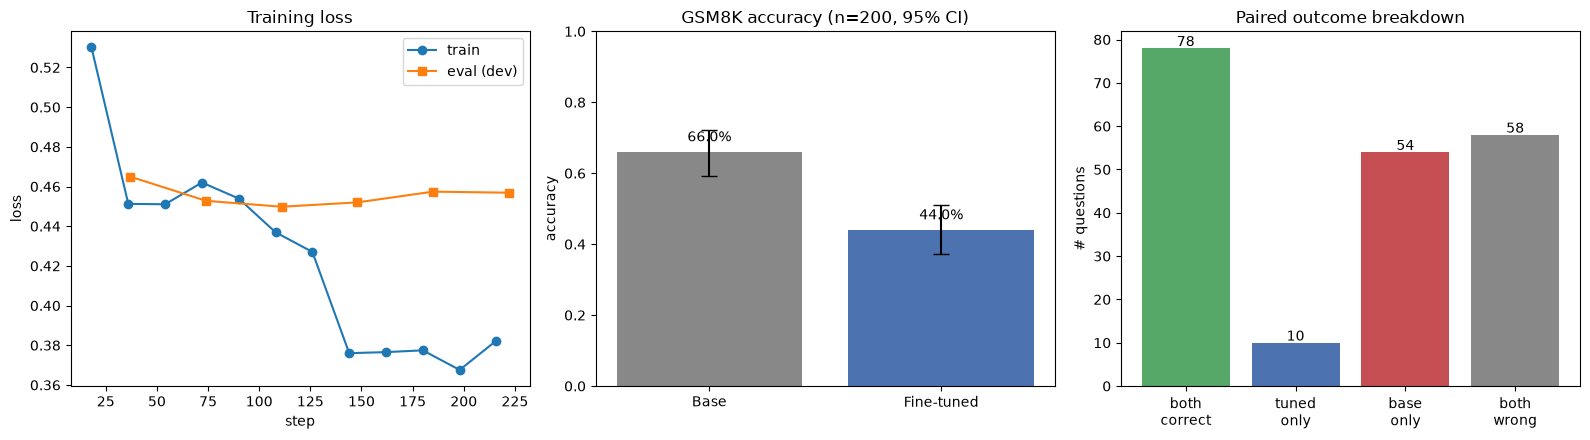

In [19]:
log_history = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

train_log = log_history.dropna(subset=["loss"]) if "loss" in log_history else pd.DataFrame()
eval_log  = log_history.dropna(subset=["eval_loss"]) if "eval_loss" in log_history else pd.DataFrame()
if not train_log.empty:
    axes[0].plot(train_log["step"], train_log["loss"], marker="o", label="train")
if not eval_log.empty:
    axes[0].plot(eval_log["step"], eval_log["eval_loss"], marker="s", label="eval (dev)")
axes[0].set(xlabel="step", ylabel="loss", title="Training loss")
axes[0].legend()

labels = ["Base", "Fine-tuned"]
accs = [base_acc, tuned_acc]
lowers = [base_acc - base_lo, tuned_acc - tuned_lo]
uppers = [base_hi - base_acc, tuned_hi - tuned_acc]
axes[1].bar(labels, accs, yerr=[lowers, uppers], capsize=6, color=["#888888", "#4c72b0"])
axes[1].set(ylabel="accuracy", ylim=(0, 1), title=f"GSM8K accuracy (n={len(paired)}, 95% CI)")
for i, a in enumerate(accs):
    axes[1].text(i, a + 0.03, f"{a:.1%}", ha="center")

outcome_labels = ["both\ncorrect", "tuned\nonly", "base\nonly", "both\nwrong"]
outcome_vals = [both_correct, tuned_only, base_only, both_wrong]
axes[2].bar(outcome_labels, outcome_vals, color=["#55a868", "#4c72b0", "#c44e52", "#888888"])
axes[2].set(ylabel="# questions", title="Paired outcome breakdown")
for i, v in enumerate(outcome_vals):
    axes[2].text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "comparison.png")
plt.savefig(fig_path, dpi=150)
print(f"Saved figure to {fig_path}")
plt.show()


## 18. Qualitative disagreements

The full generations for every question where the two models disagreed --
these are the individual cases underlying the paired statistics above, and
worth reading before trusting any headline number.


In [20]:
disagreements = paired[paired.base_correct != paired.tuned_correct]
print(f"{len(disagreements)} questions where base and tuned disagreed\n")

for i in disagreements.head(6).index:
    row = paired.loc[i]
    print(f"Q: {row.question}")
    print(f"   gold  : {row.gold}")
    print(f"   base  : {base_df.loc[i, 'pred_value']}  "
          f"({'correct' if row.base_correct else 'wrong'})")
    print(f"   tuned : {tuned_df.loc[i, 'pred_value']}  "
          f"({'correct' if row.tuned_correct else 'wrong'})")
    print()


64 questions where base and tuned disagreed

Q: Hannah needs to drink 100 ml of water for every 200 calories she burns. She spends 2 hours doing aerobics, which burns 500 calories/hour, and 1 hour running, which burns 600 calories/hour. How many ml of water does she need to drink?
   gold  : 800
   base  : 800  (correct)
   tuned : 80  (wrong)

Q: Manolo bought five lollipops and four candies that cost $3.20. If each lollipop costs $0.40, how much will 10 lollipops and 10 candies cost him?
   gold  : 7
   base  : 7  (correct)
   tuned : 14.8  (wrong)

Q: Cars have lined up on the motorway. Some of the cars drive through in the first 15 minutes of the traffic jam, then 20 more cars drive through in the remaining 15 minutes of the jam. 5 cars from the line take an exit so they don't have to drive through the traffic jam. If there were originally 30 cars on the motorway, how many cars drove through the traffic jam in the first 15 minutes?
   gold  : 5
   base  : 5  (correct)
   tuned : 45

## 19. Loading the saved model later

Once saved, the merged model can be loaded on its own -- no adapter directory,
no `peft` import required -- exactly like any other Hugging Face checkpoint.


In [21]:
from transformers import pipeline

loaded_tokenizer = AutoTokenizer.from_pretrained(MERGED_DIR)
loaded_model = AutoModelForCausalLM.from_pretrained(
    MERGED_DIR, dtype=COMPUTE_DTYPE, device_map={"": 0}
)
solver = pipeline("text-generation", model=loaded_model, tokenizer=loaded_tokenizer)

demo_question = (
    "Mark has a box of 40 chocolates. He eats 5, gives half of the remainder "
    "to his sister, then buys 10 more the next day. How many does Mark have now?"
)
demo_prompt = to_chat_example(demo_question)
result = solver(demo_prompt, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)[0]["generated_text"]
print(result[len(demo_prompt):])


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 314.03it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True 

He gave away 20 because 40 / 2 = 20
So he had 20 left after giving some to his sister.
That means he ate 30 because 40 - 20 = 20
Then he bought 10 more so he had 30 + 10 = 40
#### 40


## 20. Conclusion -- how to read the result

Compare `tuned_acc - base_acc` against the McNemar p-value and the
discordance rate printed in Section 16, not just against zero:

- **A significant gain** (`p < 0.05`, positive delta): before trusting it,
  check whether it survives on the subset where *both* models emitted a
  `#### N` line. If the gain only shows up when including generations that
  needed the last-number fallback, some of it may be an artifact of the
  fine-tuned model becoming easier to parse, not more accurate.
- **No significant change** (`p >= 0.05`): this is a legitimate result, not a
  failed experiment. With `N_EVAL=200`, the discordance-dependent minimum
  detectable difference is roughly 7-10 percentage points -- a measured swing
  smaller than that is indistinguishable from noise at this sample size.
  Raising `N_EVAL` (Section 3) tightens this at the cost of longer eval runs.
- **A significant regression** (`p < 0.05`, negative delta): look at the mean
  new-token counts in Section 16's table and the qualitative examples in
  Section 18. The most likely mechanism, flagged in the introduction, is that
  GSM8K's terse gold rationales taught the model to cut its own reasoning
  short.

Standing caveats regardless of outcome: GSM8K is a widely-used SFT dataset and
`Qwen2.5-1.5B-Instruct` has almost certainly seen similar data during its own
instruction tuning, so this experiment measures format/style adaptation more
than new mathematical capability; decoding is greedy (single deterministic
sample per question, not an average over multiple attempts); and this is one
training run with one seed and one epoch.
